Robotracking prj exploratory notebook for mobilenet v2 loading and first classification attempt

sources:
https://github.com/tensorflow/models/blob/master/research/object_detection/g3doc/tf2_detection_zoo.md

model details:
SSD MobileNet v2 320x320, speed: 19ms, output: bounding boxes

Workflow:

1. Load pre-trained model (e.g., MobileNet)
2. Fine-tune on your custom dataset
3. Save using `model.save('saved_model/')`
4. Convert to TFLite using `TFLiteConverter.from_saved_model()`
5. Deploy `.tflite` file to mobile or edge device

In [1]:
import cv2
from IPython.display import HTML
from base64 import b64encode
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
import numpy as np
from tqdm import tqdm

In [2]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
model_filepath = '/content/drive/MyDrive/Colab Notebooks/Personal_prjs/Robotracking/models/ssd_mobilenet_v2_320x320_coco17_tpu-8/saved_model'
model_filename = 'saved_model.pb'

In [4]:
model = tf.saved_model.load(model_filepath)

Test: load tennis ball to see the classfication output

In [13]:
# useful function for infer from images:

def prepro_img_for_mobilenet(image_path, x_size = 320, y_size = 320):

  image_data = tf.io.read_file(image_path)

  # Decode image (this keeps dtype uint8)
  image = tf.image.decode_image(image_data, channels=3)

  # Resize to x_size * y_size — what SSD MobileNet was trained on
  image_resized = tf.image.resize(image, (x_size, y_size))

  # Cast to uint8 (since resize converts to float32)
  image_resized = tf.cast(image_resized, dtype=tf.uint8)

  # Add batch dimension: (1, 320, 320, 3)
  input_tensor = tf.expand_dims(image_resized, axis=0)

  return image_resized, input_tensor, [x_size, y_size]


def prepro_frame(frame_image_data, x_size = 320, y_size = 320):

  # Decode image (this keeps dtype uint8)
  image = tf.convert_to_tensor(frame_image_data, dtype=tf.uint8)

  # Resize to x_size * y_size — what SSD MobileNet was trained on
  image_resized = tf.image.resize(image, (x_size, y_size))

  # Cast to uint8 (since resize converts to float32)
  image_resized = tf.cast(image_resized, dtype=tf.uint8)

  # Add batch dimension: (1, 320, 320, 3)
  input_tensor = tf.expand_dims(image_resized, axis=0)

  return image_resized, input_tensor, [x_size, y_size]


def run_inference_single_image(model, input_tensor):

  # Run inference
  model_infer_fcn = model.signatures['serving_default']
  output_dict = model_infer_fcn(input_tensor)

  # Number of detections
  num_detections = int(output_dict['num_detections'][0])

  # Get detection boxes, scores, and classes
  boxes = output_dict['detection_boxes'][0][:num_detections].numpy()  # (ymin, xmin, ymax, xmax)
  scores = output_dict['detection_scores'][0][:num_detections].numpy()
  classes = output_dict['detection_classes'][0][:num_detections].numpy().astype(int)

  return boxes, scores, classes, num_detections




def filter_on_detection_nr(classif_results, class_filter = -1, classif_th = 0.2, filter_on_detect_nr = -1):
  # classif_results = [boxes, scores, classes, num_detections]
  boxes, scores, classes, num_detections = classif_results

  # check for class_filter
  # check for scores
  # order and check for keeping only the first 'filter_on_detect_nr'

  boxes_filt = []
  scores_filt = []
  classes_filt = []

  print(class_filter)

  for i in range(num_detections):
    if ((class_filter == -1) or (class_filter != -1 and classes[i] == class_filter)):
      if scores[i] >= classif_th:
          boxes_filt.append(boxes[i])
          scores_filt.append(scores[i])
          classes_filt.append(classes[i])

  # Sort by scores descending
  sorted_indices = sorted(range(len(scores_filt)), key=lambda k: scores_filt[k], reverse=True)
  boxes_filt = [boxes_filt[i] for i in sorted_indices]
  scores_filt = [scores_filt[i] for i in sorted_indices]
  classes_filt = [classes_filt[i] for i in sorted_indices]

  # Apply filter_on_detect_nr if needed
  if filter_on_detect_nr != -1:
      boxes_filt = boxes_filt[:filter_on_detect_nr]
      scores_filt = scores_filt[:filter_on_detect_nr]
      classes_filt = classes_filt[:filter_on_detect_nr]

  num_detections_filt = len(boxes_filt)

  return boxes_filt, scores_filt, classes_filt, num_detections_filt



def get_bb_coord_resized_as_tuple(box_coord_norm, xy_resize_list):

  x_resize_factor = xy_resize_list[0]
  y_resize_factor = xy_resize_list[1]

  ymin, xmin, ymax, xmax = box_coord_norm

  # Convert normalized box coords to image pixel coords
  return (xmin * x_resize_factor, xmax * x_resize_factor, ymin * y_resize_factor, ymax * y_resize_factor)




def draw_bb_on_img(model, image_resized, input_tensor, xy_resize_list, class_filter = -1, classif_th = 0.2, filter_on_detect_nr = -1):

  # run inference on single image
  boxes, scores, classes, num_detections = run_inference_single_image(model, input_tensor)
  # filter on detections
  classif_results = [boxes, scores, classes, num_detections]
  boxes_filt, scores_filt, classes_filt, num_detections_filt = filter_on_detection_nr(classif_results, class_filter, classif_th, filter_on_detect_nr)

  # Decode image (this keeps dtype uint8)
  # Show image with boxes
  plt.figure(figsize=(8, 8))
  plt.imshow(image_resized.numpy())
  ax = plt.gca()

  # Draw boxes with scores above a threshold (classif_th)
  for i in range(num_detections_filt):

    # Convert normalized box coords to image pixel coords
    (left, right, top, bottom) = get_bb_coord_resized_as_tuple(boxes_filt[i], xy_resize_list)

    # Draw rectangle
    rect = plt.Rectangle((left, top), right - left, bottom - top,
                        fill=False, color='red', linewidth=2)
    ax.add_patch(rect)

    # Add class and score label
    label = f'Class {classes_filt[i]}: {scores_filt[i]:.2f}'
    ax.text(left, top-5, label, color='red', fontsize=8, backgroundcolor='white')

  plt.title('Detections (resized img as %ix%i)' %(xy_resize_list[0],xy_resize_list[1]))
  plt.axis('off')
  plt.show()



def infer_from_frame(model, frame, classif_params):

    x_resize            = classif_params[0]
    y_resize            = classif_params[1]
    class_filter        = classif_params[2]
    classif_th          = classif_params[3]
    filter_on_detect_nr = classif_params[4]

    # store initial frame shape
    h, w, _ = frame.shape

    # preprocess frame
    _, input_tensor, xy_resize_list = prepro_frame(frame, x_resize, y_resize)

    # run inference on single image
    boxes, scores, classes, num_detections = run_inference_single_image(model, input_tensor)
    # filter on detections
    classif_results = [boxes, scores, classes, num_detections]

    # filt on detections
    boxes_filt, scores_filt, classes_filt, num_detections_filt = filter_on_detection_nr(classif_results,
                                                                                        class_filter,
                                                                                        classif_th,
                                                                                        filter_on_detect_nr)

    frame_results = []
    for i in range(num_detections_filt):
        if scores_filt[i] >= classif_th:
            box = boxes_filt[i]
            (startY, startX, endY, endX) = (int(box[0]*h), int(box[1]*w), int(box[2]*h), int(box[3]*w))
            label = classes_filt[i]
            score = scores_filt[i]
            frame_results.append(((startX, startY, endX, endY), label, score))

    return frame_results



In [6]:
sample_img_path = '/content/drive/MyDrive/Colab Notebooks/Personal_prjs/Robotracking/images/samples/'
sample_img_filename = sample_img_path + 'tennis_ball_test5.jpg'

image_resized, input_tensor, xy_resize_list = prepro_img_for_mobilenet(sample_img_filename, x_size = 320, y_size = 320)

Display img after resizing:

37


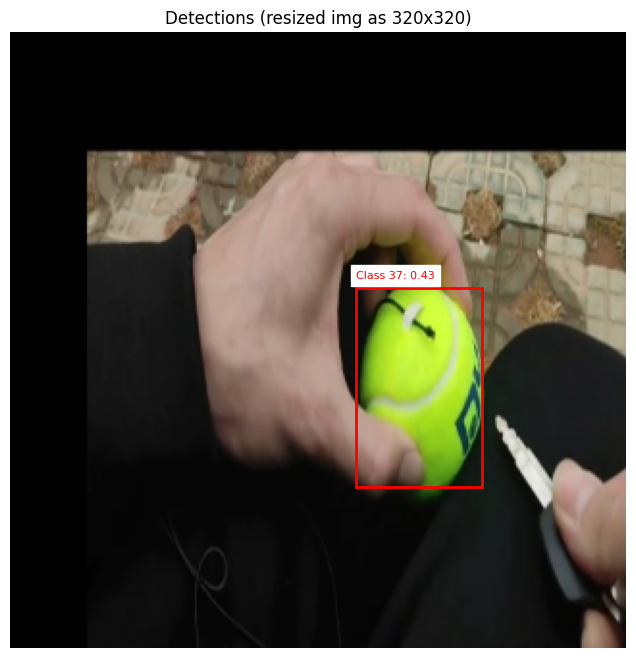

In [7]:
SPORT_BALLS_COCODATASET_ID = 37 # sport balls are mapped in class 37 for coco dataset

draw_bb_on_img(model,
               image_resized,
               input_tensor,
               xy_resize_list,
               class_filter = SPORT_BALLS_COCODATASET_ID,
               classif_th = 0.2,
               filter_on_detect_nr = 1)

Try with a recorded video:

In [17]:
def extract_frames(video_path, skip_frames=0):
    """
    Yields frames from the video, optionally skipping frames.

    video_path: path to video file
    skip_frames: number of frames to skip between reads (0 = no skipping)
    """
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0

    if not cap.isOpened():
        print("Error opening video file")
        return

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Only process every (skip_frames+1)th frame
        if frame_idx % (skip_frames + 1) == 0:
            yield frame, frame_idx  # return both frame and index

        frame_idx += 1

    cap.release()




def draw_detections(frame, detections):
    """
    Draws bounding boxes and labels on the frame.
    detections: list of (box, label, score)
    """
    for detection in detections:
        (startX, startY, endX, endY), label, score = detection

        color = (0, 255, 0)  # green box
        cv2.rectangle(frame, (startX, startY), (endX, endY), color, 2)

        text = f"{label}: {score:.2f}"
        cv2.putText(frame, text, (startX, max(startY-10, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return frame



def process_video_with_boxes(model, classif_params, video_path, output_path, skip_frames=0):
    """
    Processes a video, performs object detection, draws bounding boxes,
    and saves the output video.
    """

    cap = cv2.VideoCapture(video_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Define the video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_idx = 0

    for _ in tqdm(range(frame_count)):
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % (skip_frames + 1) == 0:

            # Run inference on the frame
            detections = infer_from_frame(model, frame, classif_params)

            # Draw detections on the frame
            frame = draw_detections(frame, detections)

        # Write the (possibly annotated) frame to the output video
        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"-- Video saved to {output_path}")

In [21]:
SPORT_BALLS_COCODATASET_ID = 37 # sport balls are mapped in class 37 for coco dataset

# classificaiton parameters
x_resize            = 320
y_resize            = 320
class_filter        = SPORT_BALLS_COCODATASET_ID
classif_th          = 0.1
filter_on_detect_nr = 1
CLASSIFC_PARAMS = [x_resize, y_resize, class_filter, classif_th, filter_on_detect_nr]

video_path = sample_img_path + 'test_video_tennis_ball1.mov'
output_path = sample_img_path + "test_video_classification.mp4"

process_video_with_boxes(model, CLASSIFC_PARAMS, video_path, output_path, skip_frames = 0)

  0%|          | 2/661 [00:00<01:29,  7.40it/s]

37
37


  1%|          | 4/661 [00:00<01:23,  7.87it/s]

37
37


  1%|          | 6/661 [00:00<01:20,  8.13it/s]

...

37


100%|█████████▉| 659/661 [01:34<00:00,  5.84it/s]

37
37


100%|██████████| 661/661 [01:34<00:00,  6.98it/s]

37
-- Video saved to /content/drive/MyDrive/Colab Notebooks/Personal_prjs/Robotracking/images/samples/test_video_classification.mp4
